# Deep Learning

## Theory
* The whole idea of deep learning is to have computers mimic biological natural intelligence
* Dendrites (the main input going into the nucleus)
* Axon (output from nucleus)

##### Perceptron Model
* Define a set of inputs going into a single point (neuron) and then combining for a single output
  * Take in x values, perform some sort of function on the values in the neuron, and then outputs y.
* We want to be able to adjust a parameter in order for the perceptron to "learn".
  * Adjustable weights are then added in, multiply the weight against x inputs
  * Originally: `y = x1 + x2`...now becomes: `y = x1w1 + x2w2`
  * Add in a bias term (b) to the inputs to help fix issues when x is 0.
    * `y = ((x1)(w1 + b)) + ((x2)(w2 + b))`
<br>
<br>
##### Neural Networks
* To build a network of perceptrons, we can connect layers of perceptrons using a multi-layer perceptron model
  * Output of a previous layer of neurons become the inputs for next layer
  * Fully connected layer: Every neuron of one layer, is connected to every neuron of the next layer
  * This allows the network as a whole to learn about interactions and relationships between features
  * First layer = Input layer
  * Last layer = Output layer
  * Hidden layers = Any layers between input and output
    * Difficult to interpret due to their interconnectivity and distance away from known input or output values
    * Hidden layers transform the input data into something more useful for the network to make accurate predictions. Each layer learns to detect increasingly abstract patterns or features in the data.
      * How do hidden layers "learn what to detect?"
        * They learn through <b>backpropagation and gradient descent</b>:
          * See backpropagation below
  * "Deep" Neural Network = 2 or more hidden layers
  * Why have multiple layers?
    * More layers = more modeling power
      * Each layer is building on the last one’s features.
    * Depth allows for abstraction
      * Layer 1 might detect lines.
      * Layer 2 might detect combinations of lines (like corners).
      * Layer 3 might detect shapes or patterns.
      * Layer 4 might recognize an object or digit.
  * <b>Activiation Functions (continuous or binary classification)</b>
    * Set boundaries to output values from the neuron
    * This non-linear function (like ReLU, sigmoid, tanh) determines how strongly that neuron "fires"
    * Inputs <b>x</b> have a weight <b>w</b> and a bias term <b>b</b> attached to them in the perceptron model `x*w+b`
      * <b>W</b> implies how much weight or strength to give the incoming input.
      * Think of <b>b</b> as an offset value, making <b>x*w</b> have to reach a certain threshold before having an effect.
      * Need to then set boundaries for the overall output value of `x*w+b`
        * `z = x*w+b`
        * And then pass <b>z</b> through some activation function to limit it's value
    * <b>Step functions (cutoffs)</b>: If our z value (in classification problems) is less than 0, then assign class 0, greater than 0, assign class 1
      * This example is not very dynamic, but we can use the sigmoid function (like in logistic regression) and it will then become more sensitive to small changes. Allows us to output a value between 0 and 1, as opposed to 0 or 1
    * <b>Hyperbolic Tangent</b>: Outputs between -1 and 1, instead of 0 and 1
      * Similar to sigmoid, but main difference is the lower boundary (floor) being -1 instead of 0
    * <b>Rectified Linear Unit (ReLU)</b>: max(0,z) - If output of value is less than 0, treat it as 0. Otherwise if greater than 0, output actual z value.
      * Have very good performance, especially when dealing with the issue of vanishing gradient.
      * Usually default to this because of performance.
<div align="center">
    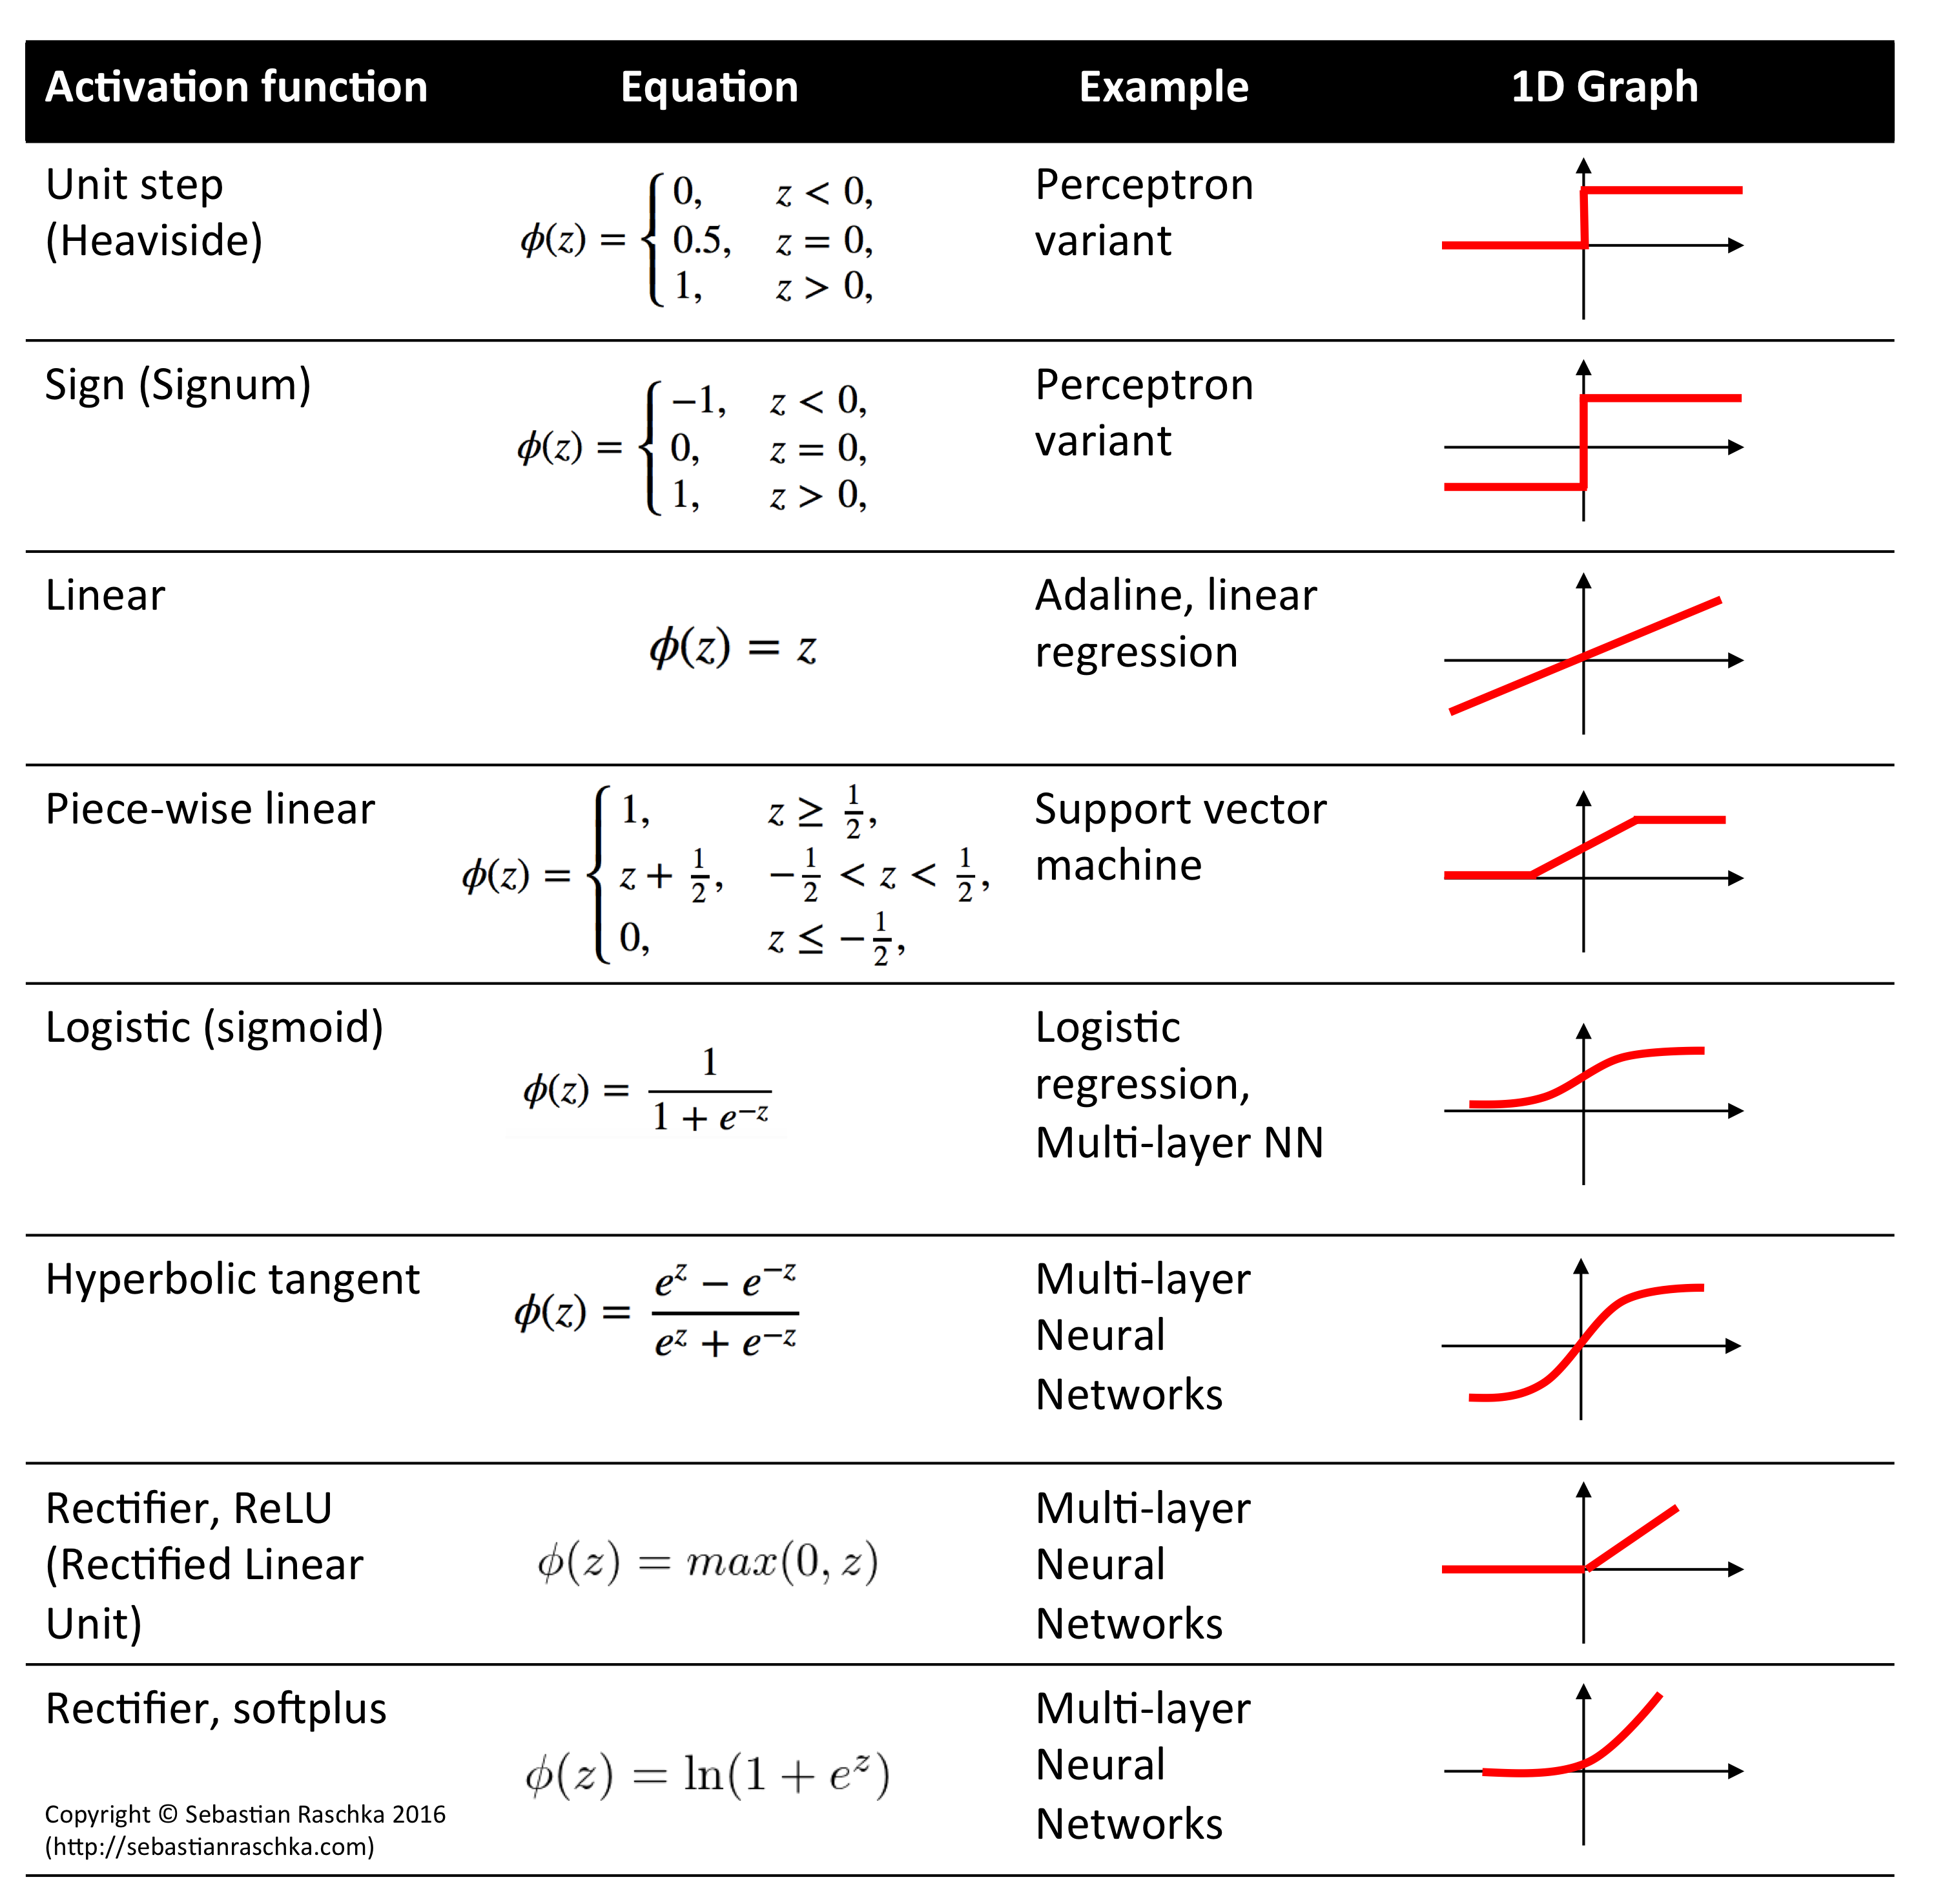
</div>

<b>Multiclass Activation Functions</b>
  * Output layer will have multiple neurons
  * 2 Main types:
    * <b>Non-Exclusive Classes</b>
      * A data point can have multiple classes/categories assigned to it
      * Photos can have multiple tags (beach, family, vacation, etc.)
      * When one-hot encoding, can have multiple "1, or yes" in the same row, whereas with mutually exclusive it is only 1
      * Sigmoid function activation function
        * Each neuron will output a value between 0 and 1 indicating the probability of having that class assigned to it
        * Allows each neuron to output independent of the other classes allowing for a single data point fed into the function to have multiple classes assigned to it
    * <b>Mutually Exclusive Classes (more common in ML)</b>
      * Only one class per data point
      * Photos can be categorized as being in grayscale or full colors, but can't be both
      * Softmax Function activation function
        * Calculates the probability distribution of the event over <i>K</i> (number of categories) different events
        * This function will calculate the probabilities of each target class over all possible target classes
      * Range is 0 to 1, and the sum of all of the probabilities will be <b>equal to one</b>
      * Model returns the probabilities of each class and the target class chosen will have the highest probability
        * Output would look like this:
          * "Red, Green, Blue"
          * "0.1, 0.6, 0.3" = 1
  * <b>Organizing Multiple Classes</b>
    * Easiest way is to simply have 1 output node per class
    * Need to organize categories for this output layer
    * Can't just have categories like "red, blue, green", because we need a numeric for the algorithm
      * Use one-hot encoding (dummy variables, like in logistic regression)
  * Once the one-hot encoding is done, we just need to choose the correct classification activation function that the last output layer should have

<b>Cost Functions & Gradient Descent</b>
  * Cost Functions (Loss Function)
    * Measures how far off we are in output predictions
    * Last output layer (ŷ) is the model's estimation of what it predicts the label to be
    * Must be an <i>average</i> so it can output a single value
    * Can keep track of our loss/cost during training to monitor network performance
    * Evaluating Performance:
      * y to represent the true value
      * a (holds info about activation function, weights, and biases) to represent neurons prediction
    * Squaring in cost function equation keeps everything positive, and punishes large errors
    * C(W, B, Sr, Er)
      * W is neural networks weights
      * B is neural networks biases
      * Sr is input of a single training sample
      * Er is desired output of that training sample
    * Need to figure out which weights lead to lowest cost (see gradient descent below)
  * Gradient Descent
    * Minimizing the error within cost functions
    * Find minimum weight value for C(w) value parabola, and do this by starting at one point, and keep heading down slope and eventually will converge on the minimum
    * Step size for each step down the slope, is known as the <b>learning rate</b>
    * Can start with larger steps, then go smaller as we realize the slope gets closer to zero <b>adaptive gradient descent</b>
    * Adam is a much more efficient way of searching for these minimums
    * When dealing with N-dimensional vectors (tensors), the notation changes from derivative to gradient
      * ∇C(w1, w2,...wn) - (∇) is the gradient
    * For classification problems, we use <b>cross entropy cost function</b>
      * The assumption is that your model predicts a probability distribution p(y=i) for each class i=1,2,...,C.

<b>Backpropagation</b>
* We want to know how the cost function results change with respect to the weights in the network. So we can update the weights to minimize
* How do hidden layers learn what to detect? 
  * The network makes a prediction.
  * It compares the prediction to the correct label (calculates loss).
  * It propagates the error backward through the network.
  * Each weight and bias is updated slightly to reduce that error.

## Keras Syntax Basics

##### Preparing Data

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
df = pd.read_csv("data/fake_reg.csv")

In [3]:
#We have historical information regarding our label, meaning it is a SUPERVISED learning problem
df.head()

,price,feature1,feature2
0,461.527929,999.787558,999.766096
1,548.130011,998.861615,1001.042403
2,410.297162,1000.070267,998.844015
3,540.382220,999.952251,1000.440940
4,546.024553,1000.446011,1000.338531


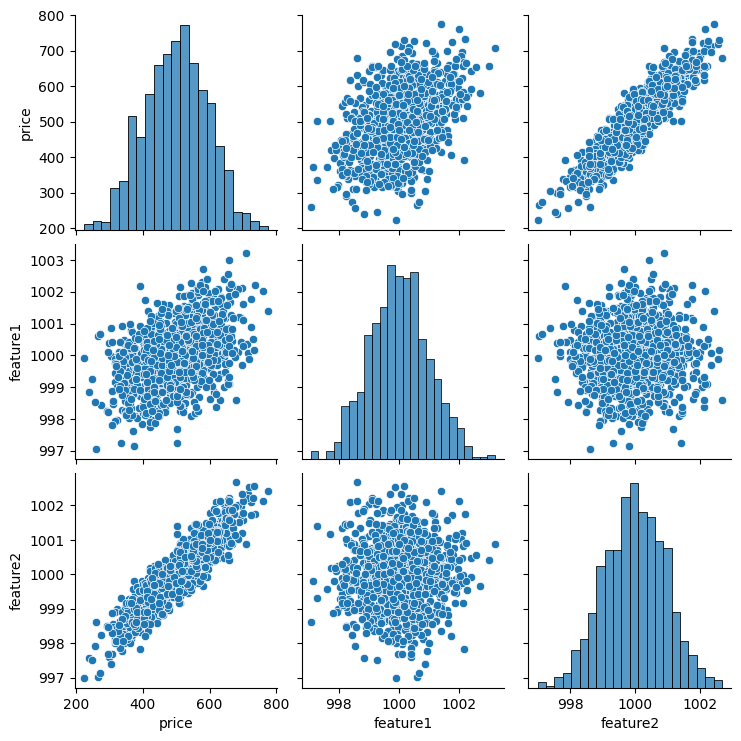

In [4]:
sns.pairplot(df)

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
#Using .values to return a numpy array of data since this is what TF needs to work with the data
X = df[['feature1','feature2']].values
y = df['price'].values

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [8]:
X_train.shape

(700, 2)

In [9]:
#Normalizing and Scaling data
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

In [10]:
#Because of MinMaxScaler, the fit below is calculating the min, max, and std dev
scaler.fit(X_train)

MinMaxScaler()

In [11]:
#Actually performing transformation
X_train = scaler.transform(X_train)

In [12]:
X_test = scaler.transform(X_test)

In [13]:
from tensorflow.keras import Sequential #Setting up a base sequential model
from tensorflow.keras.layers import Dense #Continue adding layers to it

##### Method 1

* A normal dense neural network layer. Every neuron is connected to next layer's neurons
* Units are the number of neurons in that layer, activation is the activiation function<br>
`model = Sequential[`<br>
`Dense(units=4, activation='relu'),`<br>
`Dense(units=2, activation='relu'),`<br>
`Dense(units=1) #Last layer doesn't get an activation function`<br>
`]`

##### Method 2 (Preferred for convenience)

In [14]:
# This method is preferred because if we decide we don't want a layer, we can just comment out a layer
model = Sequential()

model.add(Dense(units=4, activation='relu'))
model.add(Dense(units=4, activation='relu'))
model.add(Dense(units=4, activation='relu'))

# Last output layer and number of units is determined by the data we are trying to predict
# In this example, we are wanting a single output neuron to produce a price (our target variable)
model.add(Dense(units=1))

##### Choosing an Optimizer and Loss
* It depends on the type of problem you are solving
  * Multi-class classification:
    * `model.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])`
  * Binary classification:
    * `model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])`
  * Mean Squared Error regression:
    * `model.compile(optimizer='rmsprop', loss='mse')`

In [15]:
# Our output is then going to measured against the true price, which we can do with some sort of loss function
# Optimizer asks: "How do you want to perform this gradient descent?"
# Loss parameter takes in a string, and will change based on what we are trying to accomplish (target variable)
# In our case, since our target variable is continuous, we will use mse (see above for which optimizer and loss to use)

model.compile(optimizer='rmsprop', loss='mse')

In [16]:
# Number of epochs means the number of times you've gone through the entire dataset
model.fit(
    x=X_train,
    y=y_train,
    epochs=250
)

Epoch 1/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 258239.1719   
Epoch 2/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 267686.6562 
Epoch 3/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 257377.1406 
Epoch 4/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 260948.2656 
Epoch 5/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 259849.1875 
Epoch 6/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 257455.7969 
Epoch 7/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 254858.7188 
Epoch 8/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 255130.2344 
Epoch 9/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 255373.7031 
Epoch 10/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 255833.0781 
Epoch 11/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 256706.2656 
Epoch 12/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 258867.8281 
Epoch 13/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 256624.6719 
Epoch 14/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss

In [19]:
# Returns a dict with historical losses from the model above
model.history.history

{'loss': [256784.734375,
  256637.296875,
  256556.34375,
  256483.9375,
  256401.03125,
  256308.78125,
  256207.46875,
  256096.828125,
  255976.09375,
  255845.125,
  255702.96875,
  255547.109375,
  255373.984375,
  255182.8125,
  254972.78125,
  254742.328125,
  254489.8125,
  254213.484375,
  253912.796875,
  253585.8125,
  253228.796875,
  252844.4375,
  252428.828125,
  251980.203125,
  251494.96875,
  250976.953125,
  250421.984375,
  249822.171875,
  249181.890625,
  248498.484375,
  247770.921875,
  246993.578125,
  246168.203125,
  245285.78125,
  244360.734375,
  243379.765625,
  242338.625,
  241240.578125,
  240079.5625,
  238853.640625,
  237557.625,
  236201.34375,
  234780.84375,
  233284.984375,
  231723.546875,
  230080.15625,
  228357.03125,
  226565.140625,
  224695.8125,
  222737.828125,
  220701.765625,
  218575.609375,
  216363.015625,
  214060.640625,
  211670.375,
  209209.984375,
  206641.84375,
  203992.890625,
  201238.125,
  198402.171875,
  195481.9375,


In [20]:
# Pass it into a dataframe, and then visualize it
loss_df = pd.DataFrame(model.history.history)

<Axes: >

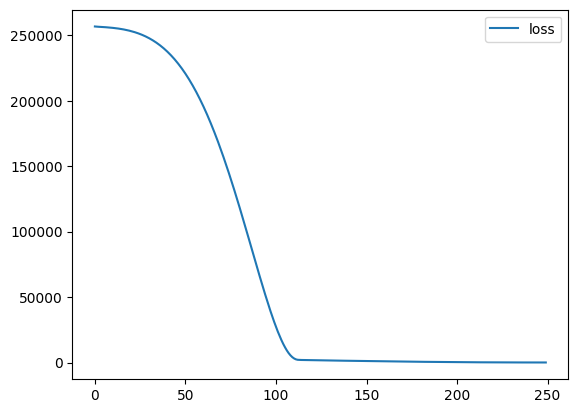

In [21]:
# Loss starts out very high, but as the weights and biases get adjusted we see it slowly lowering the loss
loss_df.plot()

## Model Evaluation

In [32]:
# Returns back the model's loss on the test data
# This is a means of interpreting results to see how well the model is performing
losseval = model.evaluate(
    x=X_test,
    y=y_test,
    verbose=0
)
print(f"Test MSE: {round(losseval, 2)}")

Test MSE: 28.8


In [33]:
# Returns back the model's loss on the test data
losseval2 = model.evaluate(
    x=X_train,
    y=y_train,
    verbose=0
)
print(f"Train MSE: {round(losseval2, 2)}")

Train MSE: 27.28


In [34]:
test_predictions = model.predict(X_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


In [49]:
pred_df = pd.DataFrame(test_predictions, columns=['x_test_pred'])
true_df = pd.DataFrame(y_test, columns=['y_test_true'])

eval_df = pd.concat([pred_df, true_df], axis=1)

In [50]:
eval_df.head()

,x_test_pred,y_test_true
0,407.942474,402.296319
1,622.617981,624.156198
2,591.474121,582.455066
3,572.716553,578.588606
4,370.996185,371.224104


<Axes: xlabel='y_test_true', ylabel='x_test_pred'>

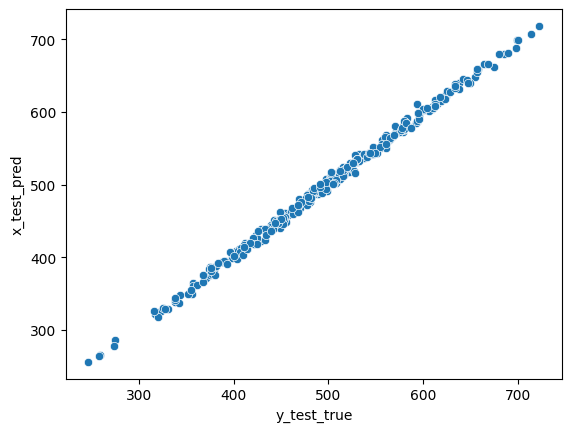

In [51]:
sns.scatterplot(x='y_test_true', y='x_test_pred', data=eval_df)

In [60]:
from sklearn.metrics import mean_absolute_error as mae, mean_squared_error as mse_

##### Mean Absolute Error (MAE)

In [55]:
# MAE of around 4, meaning we are about $4 off from the price point
# This is pretty good given that the average price is $498.67
# Think: "$4 off for the price of a house, is pretty accurate; but $4 off for the price of a candy bar is very inaccurate"
mae = mae(eval_df['x_test_pred'], eval_df['y_test_true'])
mae

4.367715680126849

In [54]:
df.describe()

,price,feature1,feature2
count,1000.000000,1000.000000,1000.000000
mean,498.673029,1000.014171,999.979847
std,93.785431,0.974018,0.948330
min,223.346793,997.058347,996.995651
25%,433.025732,999.332068,999.316106
50%,502.382117,1000.009915,1000.002243
75%,564.921588,1000.637580,1000.645380
max,774.407854,1003.207934,1002.666308


In [56]:
mean_price = df['price'].mean()
print(f"Our model is about {round(mae/mean_price, 2)}% off in terms of prediction accuracy")

Our model is about 0.01% off in terms of prediction accuracy


##### Mean Squared Error (MSE)

In [61]:
mse = mse_(eval_df['x_test_pred'], eval_df['y_test_true'])
mse

28.80368140733569

##### Root Mean Squared Error (RMSE)

In [62]:
mse_(eval_df['x_test_pred'], eval_df['y_test_true'])**0.5

5.366906129916536

##### Predicting on new data

In [63]:
new_gem = [[998, 1000]]

In [64]:
new_gem = scaler.transform(new_gem)

In [68]:
new_price = model.predict(new_gem)
new_price

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


array([[423.11987]], dtype=float32)

In [72]:
# Can use .item() to get value from numpy array, returns without brackets
print(f"New data point price is ${round(new_price.item(), 2)}")

New data point price is $423.12


##### Saving Models
`from tensorflow.keras.models import load_model`<br>
`model.save('gem model.h5')`<br>
`later_model = load_model('gem model.h5')`<br>
`later_model.predict(new_gem)`<br>